RAG Steps

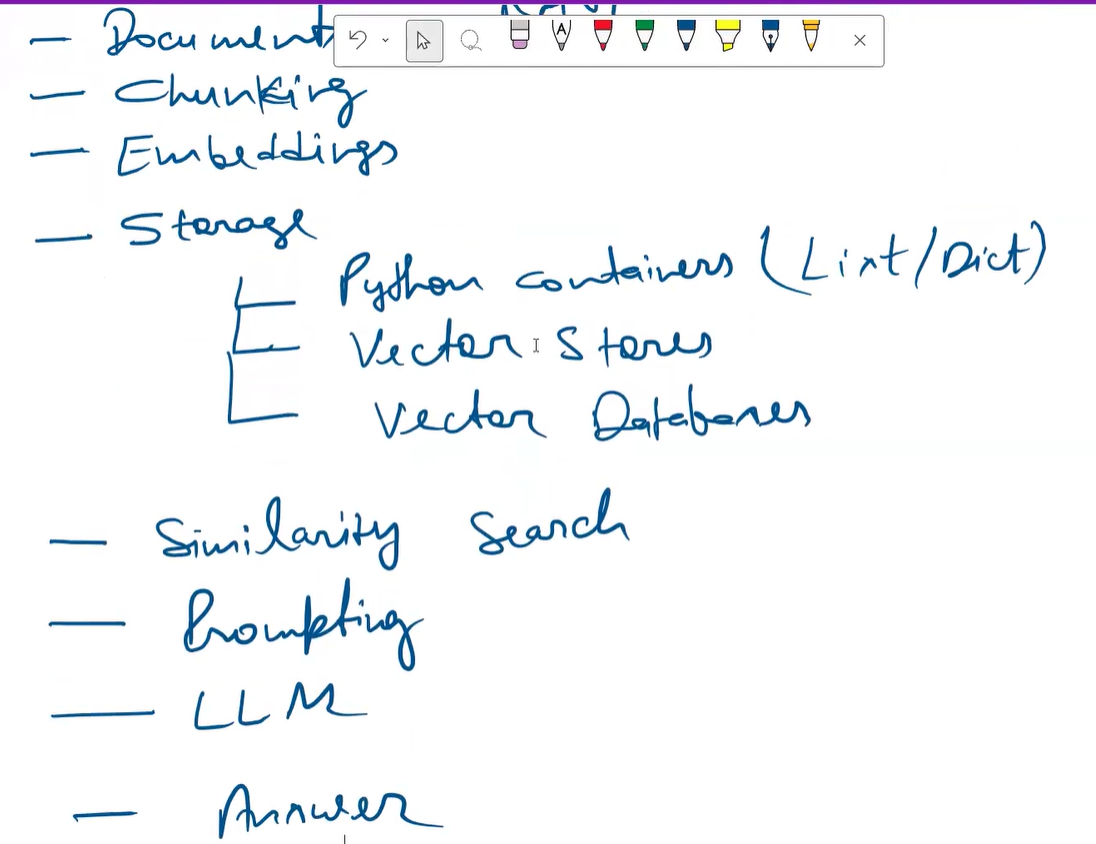


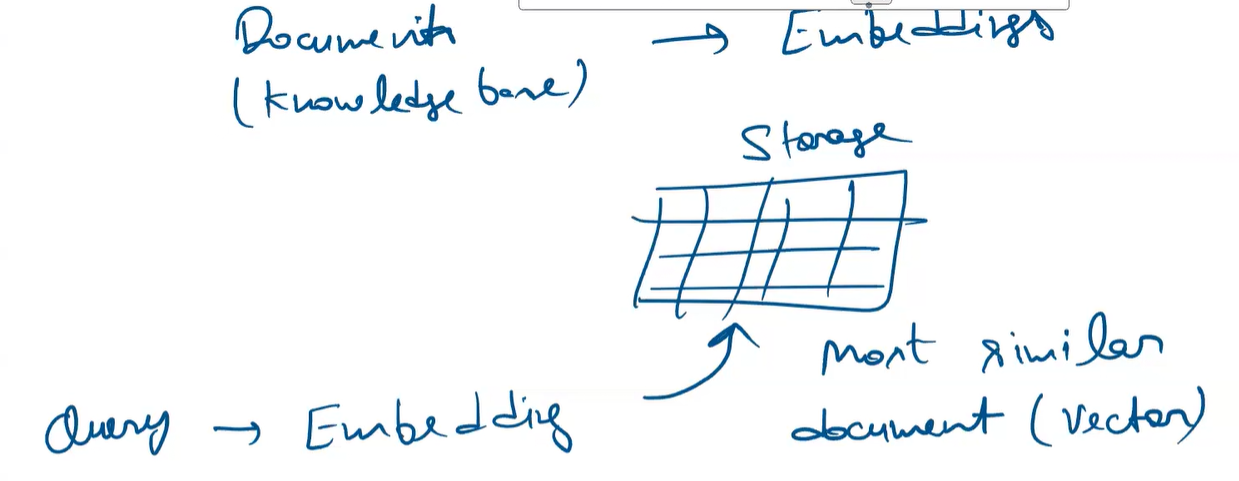

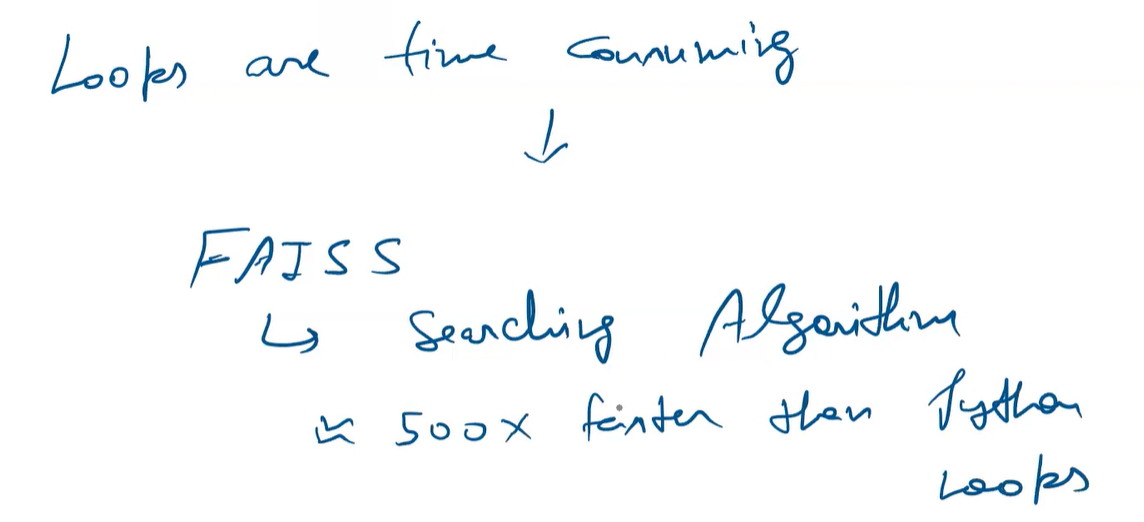

1st Technique

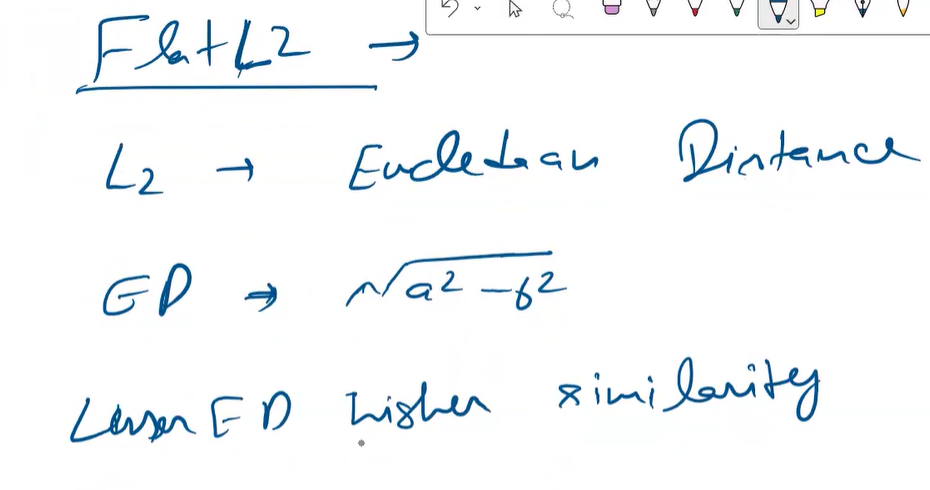


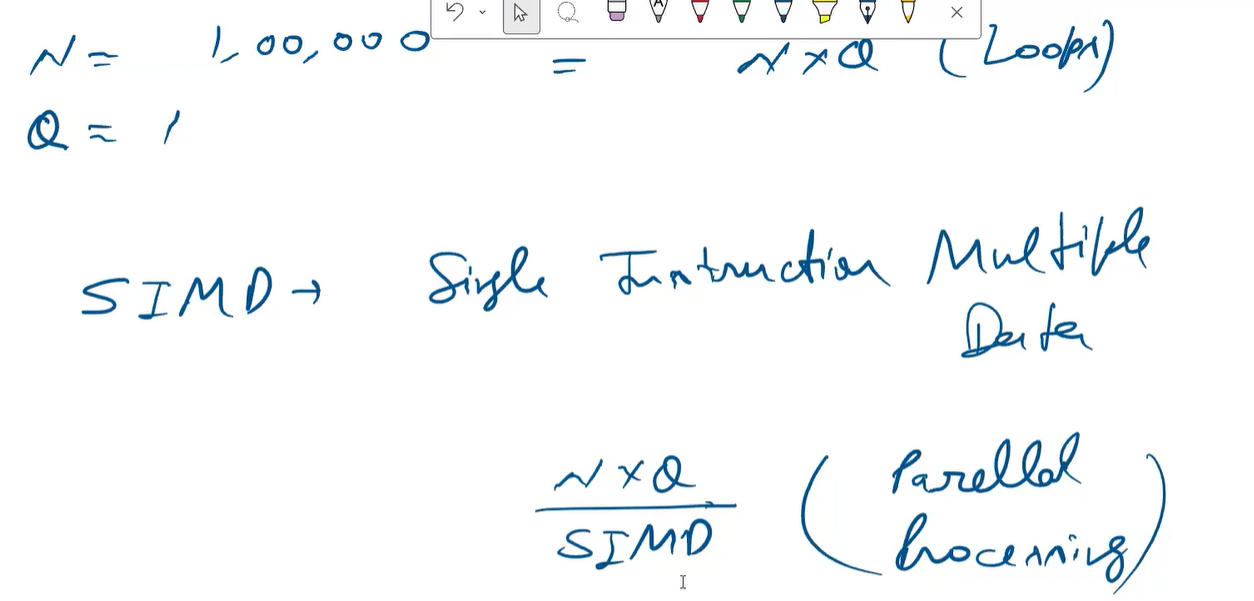

## FAISS

In [1]:
# Facebook AI Similarity Search (By Meta)

In [2]:
%pip install faiss-cpu

  Using cached faiss_cpu-1.13.2-cp313-cp313-win_amd64.whl.metadata (7.6 kB)
Using cached faiss_cpu-1.13.2-cp313-cp313-win_amd64.whl (18.9 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import os
import faiss
import numpy as np
from openai import OpenAI

In [4]:
documents = [
	"LangChain is used to build LLM applications.",
	"FAISS is used for fast similarity search.",
	"ChromaDB is a vector database.",
	"Pandas is used for data analysis.",
	"Python is a programming language.",
	"Embeddings convert text into vectors.",
	"Transformers are used in modern AI models.",
	"Vector databases store embeddings.",
	"RAG improves LLM accuracy.",
	"Machine learning learns patterns from data."
]

In [6]:
client = OpenAI(api_key=os.getenv('OPENAI_SECRET_KEY'))

### Create Embeddings

In [8]:
# create embeddings

def get_embeddings(text):
    response = client.embeddings.create(
        model='text-embedding-3-small',
        input=text
    )
    return response.data[0].embedding

In [9]:
embeddings = []
for doc in documents:
    embeddings.append(get_embeddings(doc))

In [12]:
type(embeddings[0][0])

float

In [13]:
# FAISS supports float32 type (because it uses C++)

embeddings = np.array(embeddings).astype('float32')
embeddings

array([[-0.00186947,  0.00834927,  0.05560773, ..., -0.05031176,
         0.00047454,  0.00468464],
       [-0.03728394, -0.01248207,  0.02066714, ...,  0.02972849,
        -0.0331557 ,  0.00624753],
       [ 0.03063371,  0.06956038,  0.02769347, ...,  0.00554121,
         0.00635166, -0.00400512],
       ...,
       [-0.02899029,  0.01838556,  0.02821463, ...,  0.00681126,
         0.01739175,  0.01873703],
       [ 0.00890333,  0.01073831,  0.02652648, ..., -0.00634169,
        -0.00611415, -0.01153836],
       [-0.03917453, -0.01679346,  0.03032407, ..., -0.01833311,
         0.00199085,  0.01849625]], shape=(10, 1536), dtype=float32)

In [15]:
type(embeddings[0][0])

numpy.float32

In [17]:
embeddings.shape # 1536 is the vector size if each document.

(10, 1536)

### FAISS FlatL2 Search Technique

In [22]:
# The dimension of each vector is 1536

embeddings.shape[1]

1536

In [25]:
# Step 1: Create Dimensions for Each Vector
dimensions = embeddings.shape[1]

# Step 2: Create Indexes
index_flat = faiss.IndexFlatL2(dimensions)

# Step 3: Add Vectors
index_flat.add(embeddings)

In [26]:
index_flat

<faiss.swigfaiss_avx2.IndexFlatL2; proxy of <Swig Object of type 'faiss::IndexFlatL2 *' at 0x000001658DEEF090> >

In [29]:
query = 'Tell me about Vectors'
query_emb = get_embeddings(query)

In [31]:
np.array([query_emb])

array([[ 0.00879873,  0.04398615, -0.04545636, ..., -0.00276976,
         0.00209654,  0.04683655]], shape=(1, 1536))

In [32]:
query_emb = np.array([query_emb]).astype('float32')
query_emb

array([[ 0.00879873,  0.04398615, -0.04545636, ..., -0.00276976,
         0.00209654,  0.04683655]], shape=(1, 1536), dtype=float32)

In [33]:
# Step 4: Calculate distance among the vectors

distance, indices = index_flat.search(query_emb, k = 2)

In [34]:
distance

array([[1.0143635, 1.083713 ]], dtype=float32)

In [35]:
indices

array([[7, 5]])

In [36]:
for i in indices[0]:
    print(documents[i])

Vector databases store embeddings.
Embeddings convert text into vectors.
